<a href="https://colab.research.google.com/github/oliGAMER/ML_Paper_Reprod/blob/M3_Own_Experiment/AMR_EnsembleNet_%E2%80%94_Feature_Selection_k_Sweep_(_k_SNPs_vs_Performance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AMR-EnsembleNet — Feature Selection $k$-Sweep ($k$ SNPs vs. Performance)

This notebook evaluates whether the full 60,936 SNP feature matrix is required or if a reduced subset ($k$ features selected via Chi-squared scoring) retains performance.

It uses `np.logspace` to space out $k$-values from 100 to 60,936 logarithmically, fitting `SNPFeatureSelector(k)` on the **training set only** (to prevent data leakage), training XGBoost on the reduced matrix, and evaluating performance.

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import shutil
import os

# Update paths to reflect Google Drive location
snp_path_drive = "/content/drive/MyDrive/Giessen_dataset/Giessen_dataset/cip_ctx_ctz_gen_multi_data.csv"
pheno_path_drive = "/content/drive/MyDrive/Giessen_dataset/Giessen_dataset/cip_ctx_ctz_gen_pheno.csv"

# Define local paths for the working directory
local_data_dir = "./Giessen_dataset"
os.makedirs(local_data_dir, exist_ok=True)

snp_path_local = os.path.join(local_data_dir, "cip_ctx_ctz_gen_multi_data.csv")
pheno_path_local = os.path.join(local_data_dir, "cip_ctx_ctz_gen_pheno.csv")

# Copy files from Drive to local working directory
print(f"Copying {snp_path_drive} to {snp_path_local}")
shutil.copy(snp_path_drive, snp_path_local)
print(f"Copying {pheno_path_drive} to {pheno_path_local}")
shutil.copy(pheno_path_drive, pheno_path_local)

# Use local paths for loading DataFrames
snp_path = snp_path_local
pheno_path = pheno_path_local

# Load the datasets
snp_df = pd.read_csv(snp_path)
pheno_df = pd.read_csv(pheno_path)

print("--- SNP DataFrame Head ---")
display(snp_df.head())

print("\n--- Phenotype DataFrame Head ---")
display(pheno_df.head())

Copying /content/drive/MyDrive/Giessen_dataset/Giessen_dataset/cip_ctx_ctz_gen_multi_data.csv to ./Giessen_dataset/cip_ctx_ctz_gen_multi_data.csv
Copying /content/drive/MyDrive/Giessen_dataset/Giessen_dataset/cip_ctx_ctz_gen_pheno.csv to ./Giessen_dataset/cip_ctx_ctz_gen_pheno.csv
--- SNP DataFrame Head ---


,prename,X393,X588,X747,X759,X774,X966,X1299,X1302,X1407,...,X4639956.3,X4640785.3,X4640908.3,X4640924.3,X4641031.3,X4641131.3,X4641217.3,X4641296.3,X4641439.3,X4641440.3
0,H100_S2_L001,2,1,2,4,3,3,3,3,4,...,3,4,4,2,1,3,1,3,3,1
1,H105_S3_L001,2,1,2,4,3,3,3,3,4,...,3,4,4,2,1,3,1,3,3,1
2,H108_S5_L001,2,1,2,4,3,3,0,0,4,...,3,4,4,2,1,3,1,3,3,1
3,H109_S2_L001,2,1,2,4,3,3,3,3,4,...,3,4,4,2,1,3,1,3,3,1
4,H113_S6_L001,0,0,2,4,3,3,3,3,4,...,3,4,0,0,2,3,1,3,3,1



--- Phenotype DataFrame Head ---


,prename,CIP,CTX,CTZ,GEN
0,H100_S2_L001,0,1,0,0
1,H105_S3_L001,1,1,0,0
2,H108_S5_L001,0,1,0,0
3,H109_S2_L001,0,1,0,0
4,H113_S6_L001,1,1,0,0


In [5]:
import os
from google.colab import files

print("--- Step 1: Checking or Uploading Dataset ---")

os.makedirs("Giessen_dataset", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)

snp_path = "Giessen_dataset/cip_ctx_ctz_gen_multi_data.csv"
pheno_path = "Giessen_dataset/cip_ctx_ctz_gen_pheno.csv"

if not os.path.exists(snp_path) or not os.path.exists(pheno_path):
    print("Dataset files not found. Please upload 'cip_ctx_ctz_gen_multi_data.csv' and 'cip_ctx_ctz_gen_pheno.csv':")
    uploaded = files.upload()

    for filename in uploaded.keys():
        if "multi" in filename:
            os.rename(filename, snp_path)
            print(f"Saved {filename} to {snp_path}")
        elif "pheno" in filename:
            os.rename(filename, pheno_path)
            print(f"Saved {filename} to {pheno_path}")
else:
    print("Dataset files already present locally!")

--- Step 1: Checking or Uploading Dataset ---
Dataset files not found. Please upload 'cip_ctx_ctz_gen_multi_data.csv' and 'cip_ctx_ctz_gen_pheno.csv':


KeyboardInterrupt: 

In [9]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, matthews_corrcoef
)
SEED = 42

# --- 1. Optimized Log-Space K-Values ---
K_VALUES = [int(x) for x in np.logspace(np.log10(100), np.log10(60936), num=10)]
if 60936 not in K_VALUES:
    K_VALUES.append(60936)
K_VALUES = sorted(list(set(K_VALUES)))
print(f"Evaluated K-Values (Log-spaced): {K_VALUES}")

ANTIBIOTICS = ["CIP", "CTX", "CTZ", "GEN"]
TEST_SPLIT = 0.2

XGB_PARAMS = dict(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", n_jobs=-1, random_state=SEED,
    eval_metric="logloss"
)

DECISION_THRESHOLDS = {"CIP": 0.30, "CTX": 0.50, "CTZ": 0.62, "GEN": 0.505}

Evaluated K-Values (Log-spaced): [100, 203, 415, 847, 1728, 3524, 7187, 14655, 29884, 60935, 60936]


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from scipy import stats

class SNPFeatureSelector:
    """
    Selects top k features based on a custom categorical Chi-squared test
    computed on the training set only (preventing data leakage).
    Includes p-value calculation and statistical significance evaluation.
    """
    def __init__(self, k=5000, verbose=True):
        self.k = k
        self.selected_indices_ = None
        self.verbose = verbose

    def _custom_chi2(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.int64)

        n_samples = X.shape[0]
        classes = np.unique(y)
        n_classes = len(classes)

        chi2_scores = np.zeros(X.shape[1])
        sample_contingency = None

        # Fixed categories for SNP token space (0, 1, 2, 3, 4)
        categories = np.arange(5)

        for j in range(X.shape[1]):
            feature_col = X[:, j]

            observed = np.zeros((len(categories), n_classes))
            for r, cat in enumerate(categories):
                for c, cls in enumerate(classes):
                    observed[r, c] = np.sum((feature_col == cat) & (y == cls))

            if j == 0 and self.verbose:
                sample_contingency = observed

            row_sums = observed.sum(axis=1, keepdims=True)
            col_sums = observed.sum(axis=0, keepdims=True)
            total_sum = n_samples

            expected = (row_sums @ col_sums) / total_sum

            with np.errstate(divide='ignore', invalid='ignore'):
                stat = np.where(expected > 0, ((observed - expected) ** 2) / expected, 0.0)

            chi2_scores[j] = np.sum(stat)

        if self.verbose and sample_contingency is not None:
            print("\n--- Diagnostic: Contingency Table (Feature 0) ---")
            print(sample_contingency)
            print(f"Computed Chi2 Statistic for Feature 0: {chi2_scores[0]:.6f}\n")

        return chi2_scores

    def compute_significance(self, X, y):
        """Computes chi2 scores and evaluates statistical significance via p-values."""
        chi2_scores = self._custom_chi2(X, y)
        chi2_scores = np.nan_to_num(chi2_scores, nan=0.0)

        # Degrees of freedom: (categories - 1) * (classes - 1) = (5 - 1) * (2 - 1) = 4
        df = (5 - 1) * (2 - 1)
        p_values = stats.chi2.sf(chi2_scores, df=df)

        # Bonferroni corrected threshold for multiple testing
        alpha_bonferroni = 0.05 / X.shape[1]
        significant_mask = p_values < alpha_bonferroni

        if self.verbose:
            print(f"Total features analyzed: {X.shape[1]}")
            print(f"Bonferroni-significant features (p < {alpha_bonferroni:.2e}): {np.sum(significant_mask)}")

        return chi2_scores, p_values

def load_split(antibiotic):
    # Use the globally defined snp_path and pheno_path from Google Drive
    snp_df_raw = pd.read_csv(snp_path)
    pheno_df = pd.read_csv(pheno_path)

    index_col = 'prename' if 'prename' in snp_df_raw.columns else snp_df_raw.columns[0]
    snp_df = snp_df_raw.set_index(index_col)
    pheno_df = pheno_df.set_index(index_col)

    merged_df = snp_df.join(pheno_df[antibiotic], how='inner')
    merged_df = merged_df.dropna(subset=[antibiotic]).fillna(0)

    labels = merged_df[antibiotic].values.astype(np.int32)
    X = merged_df.drop(columns=[antibiotic]).values.astype(np.int32)

    # TEST_SPLIT and SEED are defined in cell 2uqZAvvyZl2k
    return train_test_split(X, labels, test_size=TEST_SPLIT, random_state=SEED, stratify=labels)


=== Running k-sweep for CIP ===

--- Diagnostic: Contingency Table (Feature 0) ---
[[ 63.  66.]
 [  0.   0.]
 [291. 227.]
 [  0.   0.]
 [  0.   0.]]
Computed Chi2 Statistic for Feature 0: 2.245908

Total features analyzed: 60936
Bonferroni-significant features (p < 8.21e-07): 3886
  Including k=3886 (Bonferroni significant features) in sweep for CIP.
  Effective K-Values for CIP: [100, 203, 415, 847, 1728, 3524, np.int64(3886), 7187, 14655, 29884, 60935, 60936]
  k=   100 | acc=0.8889 | auc=0.9629 | mcc=0.7794
  k=   203 | acc=0.9012 | auc=0.9702 | mcc=0.8042
  k=   415 | acc=0.9012 | auc=0.9752 | mcc=0.8042
  k=   847 | acc=0.9198 | auc=0.9760 | mcc=0.8405
  k=  1728 | acc=0.9321 | auc=0.9771 | mcc=0.8654
  k=  3524 | acc=0.9506 | auc=0.9803 | mcc=0.9008
  k=  3886 | acc=0.9506 | auc=0.9815 | mcc=0.9008
  k=  7187 | acc=0.9321 | auc=0.9797 | mcc=0.8654
  k= 14655 | acc=0.9321 | auc=0.9809 | mcc=0.8654
  k= 29884 | acc=0.9321 | auc=0.9841 | mcc=0.8654
  k= 60935 | acc=0.9383 | auc=0.9

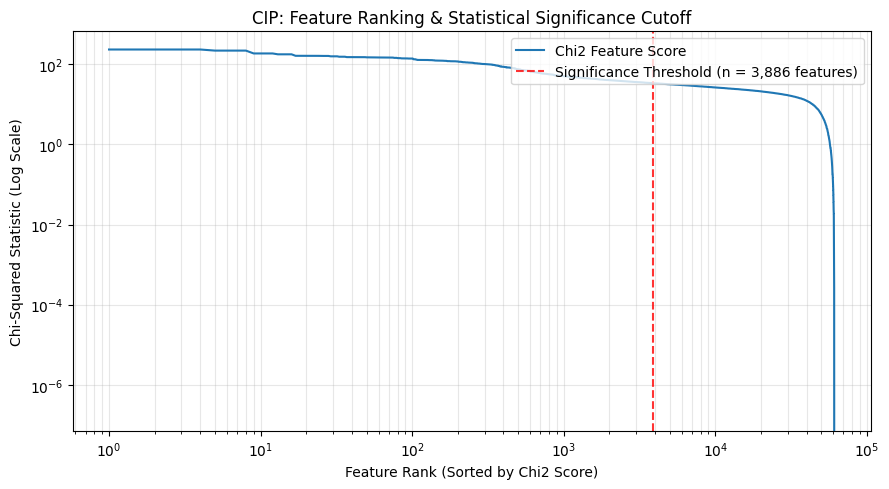


=== Running k-sweep for CTX ===

--- Diagnostic: Contingency Table (Feature 0) ---
[[ 59.  82.]
 [  0.   0.]
 [302. 204.]
 [  0.   0.]
 [  0.   0.]]
Computed Chi2 Statistic for Feature 0: 14.229241

Total features analyzed: 60936
Bonferroni-significant features (p < 8.21e-07): 786
  Including k=786 (Bonferroni significant features) in sweep for CTX.
  Effective K-Values for CTX: [100, 203, 415, np.int64(786), 847, 1728, 3524, 7187, 14655, 29884, 60935, 60936]
  k=   100 | acc=0.7593 | auc=0.8131 | mcc=0.5247
  k=   203 | acc=0.7593 | auc=0.8308 | mcc=0.5279
  k=   415 | acc=0.7346 | auc=0.8176 | mcc=0.4694
  k=   786 | acc=0.7222 | auc=0.8110 | mcc=0.4568
  k=   847 | acc=0.7160 | auc=0.8096 | mcc=0.4392
  k=  1728 | acc=0.7407 | auc=0.8263 | mcc=0.4785
  k=  3524 | acc=0.7778 | auc=0.8665 | mcc=0.5514
  k=  7187 | acc=0.7901 | auc=0.8670 | mcc=0.5764
  k= 14655 | acc=0.7778 | auc=0.8795 | mcc=0.5553
  k= 29884 | acc=0.8025 | auc=0.8793 | mcc=0.6050
  k= 60935 | acc=0.7963 | auc=0.875

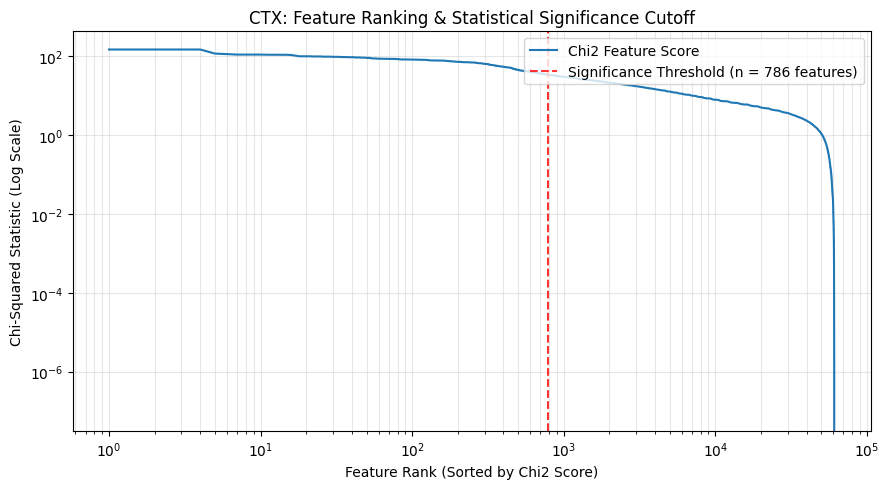


=== Running k-sweep for CTZ ===

--- Diagnostic: Contingency Table (Feature 0) ---
[[ 78.  51.]
 [  0.   0.]
 [348. 170.]
 [  0.   0.]
 [  0.   0.]]
Computed Chi2 Statistic for Feature 0: 2.071518

Total features analyzed: 60936
Bonferroni-significant features (p < 8.21e-07): 724
  Including k=724 (Bonferroni significant features) in sweep for CTZ.
  Effective K-Values for CTZ: [100, 203, 415, np.int64(724), 847, 1728, 3524, 7187, 14655, 29884, 60935, 60936]
  k=   100 | acc=0.7901 | auc=0.7845 | mcc=0.5320
  k=   203 | acc=0.8025 | auc=0.7943 | mcc=0.5596
  k=   415 | acc=0.8210 | auc=0.8043 | mcc=0.5960
  k=   724 | acc=0.8210 | auc=0.8005 | mcc=0.5960
  k=   847 | acc=0.8210 | auc=0.8052 | mcc=0.5960
  k=  1728 | acc=0.8148 | auc=0.7972 | mcc=0.5836
  k=  3524 | acc=0.7963 | auc=0.8028 | mcc=0.5369
  k=  7187 | acc=0.7901 | auc=0.8304 | mcc=0.5320
  k= 14655 | acc=0.7840 | auc=0.8177 | mcc=0.5162
  k= 29884 | acc=0.7963 | auc=0.8274 | mcc=0.5478
  k= 60935 | acc=0.8086 | auc=0.8277

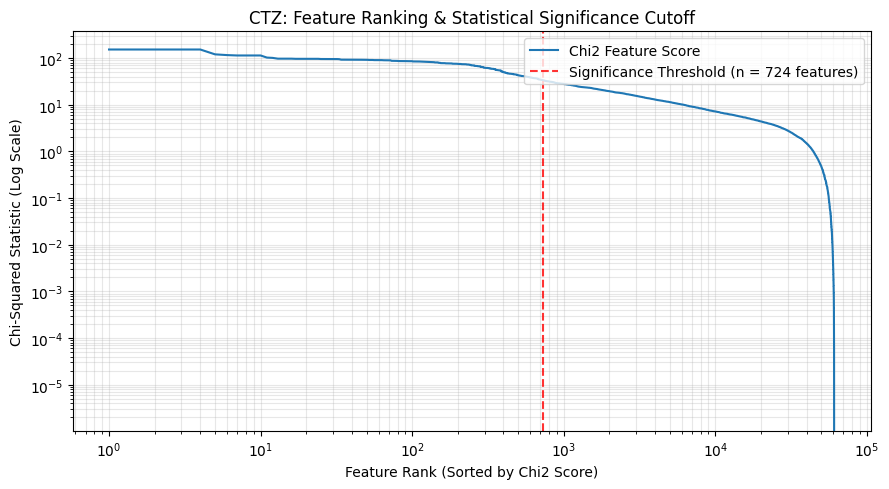


=== Running k-sweep for GEN ===

--- Diagnostic: Contingency Table (Feature 0) ---
[[ 97.  33.]
 [  0.   0.]
 [400. 117.]
 [  0.   0.]
 [  0.   0.]]
Computed Chi2 Statistic for Feature 0: 0.442421

Total features analyzed: 60936
Bonferroni-significant features (p < 8.21e-07): 349
  Including k=349 (Bonferroni significant features) in sweep for GEN.
  Effective K-Values for GEN: [100, 203, np.int64(349), 415, 847, 1728, 3524, 7187, 14655, 29884, 60935, 60936]
  k=   100 | acc=0.7284 | auc=0.7832 | mcc=0.3899
  k=   203 | acc=0.7099 | auc=0.7587 | mcc=0.3379
  k=   349 | acc=0.7346 | auc=0.7615 | mcc=0.3853
  k=   415 | acc=0.7716 | auc=0.7724 | mcc=0.4403
  k=   847 | acc=0.7469 | auc=0.7763 | mcc=0.3776
  k=  1728 | acc=0.7407 | auc=0.7831 | mcc=0.3427
  k=  3524 | acc=0.7407 | auc=0.7770 | mcc=0.3041
  k=  7187 | acc=0.7407 | auc=0.7711 | mcc=0.3041
  k= 14655 | acc=0.7469 | auc=0.7629 | mcc=0.3016
  k= 29884 | acc=0.7531 | auc=0.7719 | mcc=0.2998
  k= 60935 | acc=0.7531 | auc=0.7840

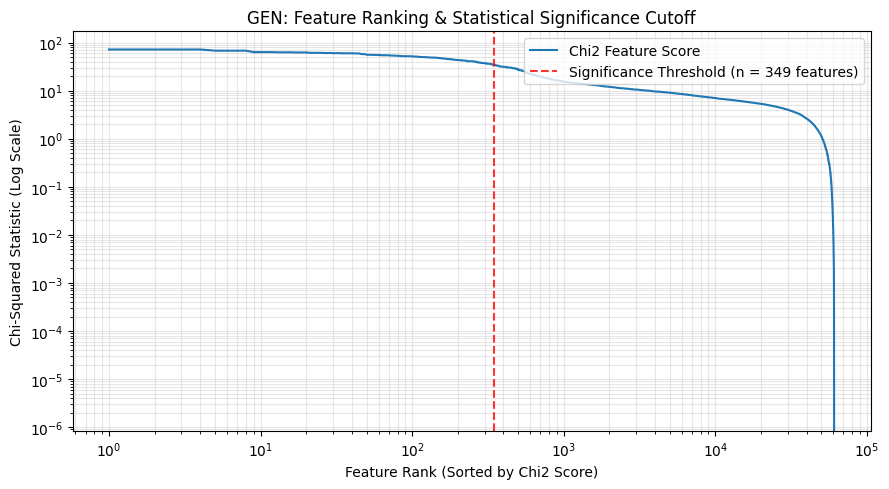


Saved k_sweep_results.csv successfully!


In [13]:
rows = []
os.makedirs("results/plots", exist_ok=True)
import matplotlib.pyplot as plt
for ab in ANTIBIOTICS:
    print(f"\n=============================")
    print(f"=== Running k-sweep for {ab} ===")
    print(f"=============================")

    X_train, X_test, y_train, y_test = load_split(ab)

    # Compute Chi2 scores and p-values ONCE for the training split (No data leakage)
    selector = SNPFeatureSelector(verbose=True)
    all_scores, all_p_values = selector.compute_significance(X_train, y_train)

    # Calculate n_significant for this antibiotic (using all_p_values)
    alpha_bonferroni = 0.05 / X_train.shape[1] # Total features in X_train
    significant_mask = all_p_values < alpha_bonferroni
    n_significant = np.sum(significant_mask)

    # Prepare the k-values list for the current antibiotic, including n_significant
    k_values_for_ab = list(K_VALUES) # Start with the base K_VALUES
    if n_significant > 0: # Only add n_significant if it's meaningful (i.e., > 0)
        k_values_for_ab.append(n_significant)
        print(f"  Including k={n_significant} (Bonferroni significant features) in sweep for {ab}.")
    else:
        print(f"  No Bonferroni significant features found for {ab} (n_significant = 0). Not adding 0 to k-sweep.")

    k_values_for_ab = sorted(list(set(k_values_for_ab))) # Sort and remove duplicates
    print(f"  Effective K-Values for {ab}: {k_values_for_ab}")


    for k in k_values_for_ab: # Use the extended list for this antibiotic
        actual_k = min(k, X_train.shape[1])

        # If actual_k is 0, skip this iteration to prevent errors with model fitting
        if actual_k == 0:
            print(f"    Skipping k={k} for {ab} as actual_k is 0 (no features selected).")
            r = {
                "antibiotic": ab,
                "k": k,
                "n_features_actual": 0,
                "accuracy": 0.0, "auc": 0.0, "mcc": 0.0, "f1_resistant": 0.0, "macro_f1": 0.0,
            } # Record zero metrics for no features
            rows.append(r)
            continue

        # Slice top-k features instantly based on pre-computed scores
        selected_indices = np.argsort(all_scores)[-actual_k:]
        Xtr = X_train[:, selected_indices]
        Xte = X_test[:, selected_indices]

        # Class imbalance weighting
        neg, pos = (y_train == 0).sum(), max((y_train == 1).sum(), 1)
        scale_pos_weight = neg / pos

        model = xgb.XGBClassifier(**XGB_PARAMS, scale_pos_weight=scale_pos_weight)
        model.fit(Xtr, y_train, verbose=False)

        y_prob = model.predict_proba(Xte)[:, 1]
        threshold = DECISION_THRESHOLDS.get(ab, 0.5)
        y_pred = (y_prob > threshold).astype(int)

        r = {
            "antibiotic": ab,
            "k": k,
            "n_features_actual": int(Xtr.shape[1]),
            "accuracy": accuracy_score(y_test, y_pred),
            "auc": roc_auc_score(y_test, y_prob),
            "mcc": matthews_corrcoef(y_test, y_pred),
            "f1_resistant": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
            "macro_f1": f1_score(y_test, y_pred, average="macro", zero_division=0),
        }
        print(f"  k={r['n_features_actual']:>6} | acc={r['accuracy']:.4f} | auc={r['auc']:.4f} | mcc={r['mcc']:.4f}")
        rows.append(r)

    # --- Generate Chi2 Feature Ranking & Significance Cutoff Plot for this Drug ---
    # degrees of freedom for chi2 test (5 SNP categories - 1) * (2 classes - 1) = 4
    df_chi2_for_plotting = 4
    # Need to recalculate sorted_scores and sorted_p_vals for plotting, as all_p_values is not sorted
    sorted_scores_for_plot = np.sort(all_scores)[::-1]
    ranks = np.arange(1, len(sorted_scores_for_plot) + 1)
    # alpha_bonferroni is already calculated above
    sorted_p_vals_for_plot = stats.chi2.sf(sorted_scores_for_plot, df=df_chi2_for_plotting)
    significant_indices_for_plot = np.where(sorted_p_vals_for_plot < alpha_bonferroni)[0]
    n_significant_for_plot = len(significant_indices_for_plot) if len(significant_indices_for_plot) > 0 else 0


    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(ranks, sorted_scores_for_plot, color="#1f77b4", linewidth=1.5, label="Chi2 Feature Score")

    if n_significant_for_plot > 0:
        ax.axvline(n_significant_for_plot, color="red", linestyle="--", alpha=0.8,
                   label=f"Significance Threshold (n = {n_significant_for_plot:,} features)")

    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlabel("Feature Rank (Sorted by Chi2 Score)")
    ax.set_ylabel("Chi-Squared Statistic (Log Scale)")
    ax.set_title(f"{ab}: Feature Ranking & Statistical Significance Cutoff")
    ax.legend(loc="upper right")
    ax.grid(alpha=0.3, which="both")

    fig.tight_layout()
    plt.savefig(f"results/plots/chi2_significance_{ab}.png", dpi=150)
    plt.show()

df_sweep = pd.DataFrame(rows)
df_sweep.to_csv("results/k_sweep_results.csv", index=False)
print("\nSaved k_sweep_results.csv successfully!")

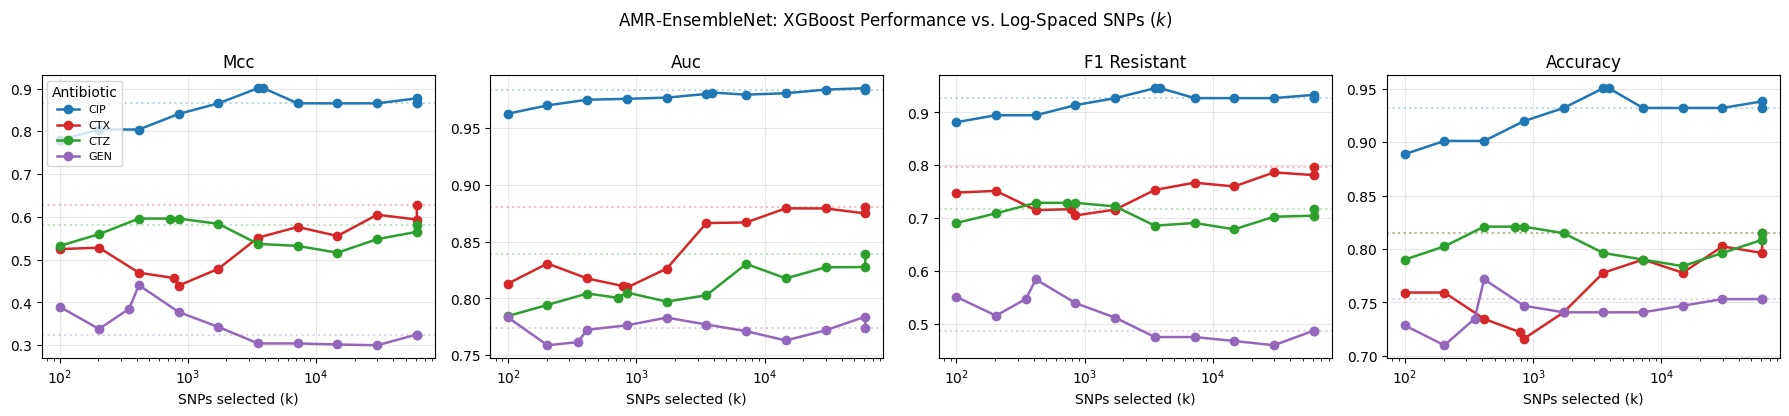

In [14]:
METRICS = ["mcc", "auc", "f1_resistant", "accuracy"]
COLORS = {"CIP": "#1f77b4", "CTX": "#d62728", "CTZ": "#2ca02c", "GEN": "#9467bd"}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharex=True)

for ax, metric in zip(axes, METRICS):
    for ab in ANTIBIOTICS:
        sub = df_sweep[df_sweep["antibiotic"] == ab].sort_values("k")
        ax.plot(sub["k"], sub[metric], marker="o", label=ab, color=COLORS[ab], linewidth=1.8)

        full = sub[sub["k"] == sub["k"].max()].iloc[0][metric]
        ax.axhline(full, linestyle=":", color=COLORS[ab], alpha=0.3)

    ax.set_xscale("log")
    ax.set_xlabel("SNPs selected (k)")
    ax.set_title(metric.replace("_", " ").title())
    ax.grid(alpha=0.3)

axes[0].legend(title="Antibiotic", fontsize=8)
plt.suptitle("AMR-EnsembleNet: XGBoost Performance vs. Log-Spaced SNPs ($k$)", fontsize=12)
plt.tight_layout()

plt.savefig("results/plots/k_sweep.png", dpi=150)
plt.show()

In [16]:
import shutil
import os

# Define the base target directory in Google Drive
drive_base_output_dir = "/content/drive/MyDrive/AMR_repro_results"

# Define the new specific output directories
m3_output_dir = os.path.join(drive_base_output_dir, "m3")
m3_plots_dir = os.path.join(m3_output_dir, "plots")

# Create the new directories
os.makedirs(m3_plots_dir, exist_ok=True)

print(f"Saving results to structured folders in Google Drive:")
print(f"  CSV will go to: {m3_output_dir}/")
print(f"  Plots will go to: {m3_plots_dir}/")

# 1. Copy the k_sweep_results.csv
local_csv_path = "results/k_sweep_results.csv"
shutil.copy(local_csv_path, m3_output_dir)
print(f"Copied {local_csv_path} to {m3_output_dir}")

# 2. Copy the main k_sweep.png plot
local_k_sweep_plot_path = "results/plots/k_sweep.png"
shutil.copy(local_k_sweep_plot_path, m3_plots_dir)
print(f"Copied {local_k_sweep_plot_path} to {m3_plots_dir}")

# 3. Copy the individual chi2_significance plots for each antibiotic
for ab in ANTIBIOTICS:
    local_chi2_plot_path = f"results/plots/chi2_significance_{ab}.png"
    shutil.copy(local_chi2_plot_path, m3_plots_dir)
    print(f"Copied {local_chi2_plot_path} to {m3_plots_dir}")

print("All results successfully saved to Google Drive!")

Saving results to structured folders in Google Drive:
  CSV will go to: /content/drive/MyDrive/AMR_repro_results/m3/
  Plots will go to: /content/drive/MyDrive/AMR_repro_results/m3/plots/
Copied results/k_sweep_results.csv to /content/drive/MyDrive/AMR_repro_results/m3
Copied results/plots/k_sweep.png to /content/drive/MyDrive/AMR_repro_results/m3/plots
Copied results/plots/chi2_significance_CIP.png to /content/drive/MyDrive/AMR_repro_results/m3/plots
Copied results/plots/chi2_significance_CTX.png to /content/drive/MyDrive/AMR_repro_results/m3/plots
Copied results/plots/chi2_significance_CTZ.png to /content/drive/MyDrive/AMR_repro_results/m3/plots
Copied results/plots/chi2_significance_GEN.png to /content/drive/MyDrive/AMR_repro_results/m3/plots
All results successfully saved to Google Drive!


In [19]:
import os
import shutil
from google.colab import userdata

# --- GitHub Repository Details ---
github_repo_url = "https://github.com/oliGAMER/ML_Paper_Reprod.git"
local_repo_dir = "ML_Paper_Reprod"
new_branch_name = "M3_Own_Experiment"

# --- Local Results Paths ---
local_results_dir = "results"
m3_local_output_dir = os.path.join(local_results_dir, "m3") # Assuming results are already in results/m3 locally or will be copied there for consistency
m3_local_plots_dir = os.path.join(m3_local_output_dir, "plots")

# --- GitHub PAT for authentication ---
gh_pat = userdata.get('GH_PAT_2')

if not gh_pat:
    print("Error: GitHub Personal Access Token (GH_PAT_2) not found in Colab secrets.\n" \
          "Please ensure it is set in 'Secrets' panel.")
else:
    print(f"Using GitHub PAT (GH_PAT_2) for authentication.")
    # Set up authenticated URL
    authenticated_repo_url = f"https://{gh_pat}@github.com/oliGAMER/ML_Paper_Reprod.git"

    # --- 1. Install Git LFS (if not already present) ---
    print("Installing Git LFS...")
    !apt-get update -qq > /dev/null
    !apt-get install -y git-lfs > /dev/null
    !git lfs install

    # --- 2. Configure Git ---
    print("Configuring Git user...")
    !git config --global user.email "colab-user@example.com"
    !git config --global user.name "Colab User"

    # --- 3. Clone the repository ---
    if os.path.exists(local_repo_dir):
        print(f"Removing existing local repository directory: {local_repo_dir}")
        shutil.rmtree(local_repo_dir)

    print(f"Cloning repository: {github_repo_url}")
    !git clone {authenticated_repo_url}

    # --- 4. Navigate into the repository and create/switch branch ---
    os.chdir(local_repo_dir)
    print(f"Creating and switching to new branch: {new_branch_name}")
    !git checkout -b {new_branch_name}

    # --- 5. Copy results into the cloned repository ---
    # Ensure the target directories exist in the cloned repo
    repo_m3_dir = os.path.join(os.getcwd(), "m3")
    repo_m3_plots_dir = os.path.join(repo_m3_dir, "plots")
    os.makedirs(repo_m3_plots_dir, exist_ok=True)

    print(f"Copying results from {local_results_dir} to {os.getcwd()}/m3/")

    # Copy CSV file
    csv_filename = "k_sweep_results.csv"
    shutil.copy(os.path.join("../", local_results_dir, csv_filename), repo_m3_dir)

    # Copy main plot
    k_sweep_plot_filename = "k_sweep.png"
    shutil.copy(os.path.join("../", local_results_dir, "plots", k_sweep_plot_filename), repo_m3_plots_dir)

    # Copy individual chi2 plots
    for ab in ['CIP', 'CTX', 'CTZ', 'GEN']:
        chi2_plot_filename = f"chi2_significance_{ab}.png"
        shutil.copy(os.path.join("../", local_results_dir, "plots", chi2_plot_filename), repo_m3_plots_dir)

    # --- 6. Add, commit, and push ---
    print("Adding changes to Git...")
    !git add .

    print("Committing changes...")
    !git commit -m "feat: Add M3 k-sweep results and plots from Colab experiment"

    print(f"Pushing to {new_branch_name} on GitHub...")
    !git push origin {new_branch_name}

    # --- 7. Clean up (optional) ---
    os.chdir("..") # Go back to the parent directory
    # shutil.rmtree(local_repo_dir) # Uncomment to remove the cloned repo after pushing

    print("\nSuccessfully pushed results to GitHub!")


Using GitHub PAT (GH_PAT_2) for authentication.
Installing Git LFS...
W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Git LFS initialized.
Configuring Git user...
Cloning repository: https://github.com/oliGAMER/ML_Paper_Reprod.git
Cloning into 'ML_Paper_Reprod'...
remote: Enumerating objects: 253, done.
remote: Counting objects: 100% (253/253), done.
remote: Compressing objects: 100% (223/223), done.
remote: Total 253 (delta 82), reused 111 (delta 18), pack-reused 0 (from 0)
Receiving objects: 100% (253/253), 36.84 MiB | 21.34 MiB/s, done.
Resolving deltas: 100% (82/82), done.
Creating and switching to new branch: M3_Own_Experiment
Switche